In [87]:
print("all ok")

all ok


In [88]:
from dotenv import load_dotenv
import os

load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")


In [89]:

from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name="openai/gpt-oss-120b",
    temperature=0
)
response=llm.invoke("what is length of wall of china?")

In [90]:
response

AIMessage(content='The Great Wall of China isn’t a single, continuous structure built all at once—it’s a network of walls, trenches, and natural barriers that were constructed, rebuilt, and expanded over many dynasties.  \n\n**Total measured length (including all known sections):**  \n\n- **≈\u202f21,196\u202fkilometers** (about **13,171\u202fmiles**)  \n\nThis figure comes from the most recent comprehensive survey carried out by China’s State Administration of Cultural Heritage in 2012, which added many previously undocumented sections (including earthen walls, mountain passes, and river‑crossing fortifications) to the total.\n\n### Why the number varies\n- **Historical phases:** Different dynasties (e.g., Qin, Han, Sui, Ming) built separate stretches. The famous “Ming Great Wall” alone is roughly 8,850\u202fkm (5,500\u202fmi).\n- **Definitions:** Some counts include only stone/brick walls, while others also count earthen ramparts, natural barriers, and auxiliary structures.\n- **Ongo

In [91]:
response.content

'The Great Wall of China isn’t a single, continuous structure built all at once—it’s a network of walls, trenches, and natural barriers that were constructed, rebuilt, and expanded over many dynasties.  \n\n**Total measured length (including all known sections):**  \n\n- **≈\u202f21,196\u202fkilometers** (about **13,171\u202fmiles**)  \n\nThis figure comes from the most recent comprehensive survey carried out by China’s State Administration of Cultural Heritage in 2012, which added many previously undocumented sections (including earthen walls, mountain passes, and river‑crossing fortifications) to the total.\n\n### Why the number varies\n- **Historical phases:** Different dynasties (e.g., Qin, Han, Sui, Ming) built separate stretches. The famous “Ming Great Wall” alone is roughly 8,850\u202fkm (5,500\u202fmi).\n- **Definitions:** Some counts include only stone/brick walls, while others also count earthen ramparts, natural barriers, and auxiliary structures.\n- **Ongoing discoveries:**

In [92]:
from langchain.tools import tool

## this is my custom tools

In [93]:
from langchain.tools import tool

@tool
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers, converting the first number to an integer before multiplication.

    Args:
        a (float): The first number. This will be converted to an integer before multiplication.
        b (float): The second number.

    Returns:
        float: The product of the integer part of 'a' and 'b'.
    """
    return int(a) * b

@tool
def add(a: float, b: float) -> float:
    """
    Add two numbers.

    Args:
        a (float): The first number.
        b (float): The second number.

    Returns:
        float: The sum of a and b.
    """
    return a + b

@tool
def divide(a: float, b: float) -> float:
    """
    Divide two numbers.

    Args:
        a (float): The numerator.
        b (float): The denominator (must not be 0).

    Returns:
        float: The result of division.
    """
    if b == 0:
        raise ValueError("Denominator cannot be zero.")
    return a / b

## importing the inbuilt tool

In [94]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [95]:
search.invoke("what is the latest update on iphone17 release?")

/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


'Breaking news from Hong Kong, China and Asia including geopolitics, diplomacy, economy, technology, lifestyle, entertainment and sport. Jul 23, 2014 · 按我个人的理解，latest 这个词强调的是时间序列上最靠近现在，而 newest 强调的是新旧的问题。比如说，苹果的 newest 产品，毫无疑问是 Mac Pro，这是去年才出现的东西，以前是没 … All the latest news, opinions and analysis on Hong Kong, China, Asia and around the world Latest news, in-depth features and opinion on Malaysia, covering politics, economy, society and the Asean member-nation’s relationships with China, Singapore, and other Southeast Asian countries. Latest news, in-depth features and opinion on Singapore, covering politics, economy, society and the city state’s relationships with China, Malaysia, and other Southeast Asian countries.'

In [96]:
# !pip install duckduckgo_search


In [97]:
tools=[multiply, add, divide, search]

In [98]:
llm_with_tools=llm.bind_tools(tools)

In [99]:
response=llm_with_tools.invoke("hi")

In [100]:
response.content

'Hello! How can I help you today?'

In [101]:
response.tool_calls

[]

In [102]:
response=llm_with_tools.invoke("what is 2+2?")

In [103]:
response.content

'2\u202f+\u202f2\u202f=\u202f4.'

In [104]:
response.tool_calls

[]

In [105]:
response=llm_with_tools.invoke("what is 10/2?")

In [106]:
response.content

''

In [107]:
response.tool_calls

[{'name': 'divide',
  'args': {'a': 10, 'b': 2},
  'id': 'fc_5011448b-110a-4e07-84bf-b48164aa9312',
  'type': 'tool_call'}]

In [108]:
response=llm_with_tools.invoke("what is a current age of the TATA Group?")

In [109]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is a current age of the TATA Group?" They want the age (how many years since founding). Need current age as of now (2025). Need to know founding year of Tata Group. Tata Group was founded in 1868 by Jamsetji Tata. So age = 2025 - 1868 = 157 years. However need to verify if it\'s 1868 or 1868? Actually Tata Group\'s origin: The company was founded in 1868 as a trading firm. So age = 2025 - 1868 = 157. If current date is Dec 27 2025, then age is 157 years (or 157 years and some months). Provide answer. Might need to confirm via search. Use duckduckgo search to verify founding year.', 'tool_calls': [{'id': 'fc_bb49d05f-56ab-4058-bc6a-25a62f72f8b9', 'function': {'arguments': '{"query":"Tata Group founded year"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 363, 'total_tokens': 566, 'completion_time': 0.425775748, 'prompt_

In [110]:
response.content

''

In [111]:
response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'Tata Group founded year'},
  'id': 'fc_bb49d05f-56ab-4058-bc6a-25a62f72f8b9',
  'type': 'tool_call'}]

In [112]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [113]:
SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs."



In [114]:
user_query=["tell me what is 2+2"]

In [115]:
[SYSTEM_PROMPT]+user_query

['You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.',
 'tell me what is 2+2']

In [116]:
def function_1(state:MessagesState):

    user_question=state["messages"]

    input_question = [SYSTEM_PROMPT]+user_question

    response = llm_with_tools.invoke(input_question)

    return {
        "messages":[response]
    }



In [117]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START

In [118]:
builder=StateGraph(MessagesState)

In [119]:
builder.add_node("llm_decision_step",function_1)

In [120]:
tools

[StructuredTool(name='multiply', description="Multiply two numbers, converting the first number to an integer before multiplication.\n\nArgs:\n    a (float): The first number. This will be converted to an integer before multiplication.\n    b (float): The second number.\n\nReturns:\n    float: The product of the integer part of 'a' and 'b'.", args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x1198979c0>),
 StructuredTool(name='add', description='Add two numbers.\n\nArgs:\n    a (float): The first number.\n    b (float): The second number.\n\nReturns:\n    float: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x119896480>),
 StructuredTool(name='divide', description='Divide two numbers.\n\nArgs:\n    a (float): The numerator.\n    b (float): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<functi

In [121]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))

In [122]:
builder.add_edge(START,"llm_decision_step")

In [123]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)


In [124]:
builder.add_edge("tools","llm_decision_step")

In [125]:
react_graph=builder.compile()

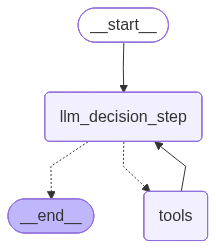

In [126]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [127]:
message=[HumanMessage(content="What is 2 times of narendramodi's age?")]

In [128]:
react_graph.invoke({"messages":message})

/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


{'messages': [HumanMessage(content="What is 2 times of narendramodi's age?", additional_kwargs={}, response_metadata={}, id='2913fb79-4462-41c2-b772-bd2a9051e38b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What is 2 times of narendramodi\'s age?" Need to find Narendra Modi\'s age. Use search. Then multiply by 2. Use arithmetic function multiply? multiply expects first number converted to int then multiplied by second. But we need 2 * age. Could use multiply with a=2, b=age. That will convert 2 to int (2) and multiply by age. Or use add? No. Use multiply.\n\nFirst search for Narendra Modi age.', 'tool_calls': [{'id': 'fc_d7f79de4-d859-44a5-93e3-94abef91f6b2', 'function': {'arguments': '{"query":"Narendra Modi age"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 387, 'total_tokens': 525, 'completion_time': 0.286795558, 'prompt_time': 0.017240837, 'queue_time':

In [129]:
message = [HumanMessage(content="How much is the net worth of Elon Musk, and divide it by 2?")]

In [130]:
react_graph.invoke({"messages":message})

/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: Runtim

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT

In [ ]:
message = [HumanMessage(content="What is the speed of light in m/s and multiply it by 10?")]

In [ ]:
response=react_graph.invoke({"messages":message})

In [ ]:
response["messages"][-1].content

'The speed of light in a vacuum is **299,792,458\u202fm/s**.  \n\nMultiplying that by 10 gives:\n\n**2,997,924,580\u202fm/s**.'

In [ ]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the speed of light in m/s and multiply it by 10?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_2fbf3841-4a8b-4f6c-8516-3677c3d64a8a)
 Call ID: fc_2fbf3841-4a8b-4f6c-8516-3677c3d64a8a
  Args:
    a: 299792458
    b: 10
================================= Tool Message =================================
Name: multiply

2997924580.0
================================== Ai Message ==================================

The speed of light in a vacuum is **299,792,458 m/s**.  

Multiplying that by 10 gives:

**2,997,924,580 m/s**.


In [ ]:
import yfinance as yf

In [ ]:
@tool
def get_stock_price(ticker:str)->str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"



In [ ]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $273.81.'

In [ ]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $485.40.'

In [ ]:
tools

[StructuredTool(name='multiply', description="Multiply two numbers, converting the first number to an integer before multiplication.\n\nArgs:\n    a (float): The first number. This will be converted to an integer before multiplication.\n    b (float): The second number.\n\nReturns:\n    float: The product of the integer part of 'a' and 'b'.", args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x788c44940b80>),
 StructuredTool(name='add', description='Add two numbers.\n\nArgs:\n    a (float): The first number.\n    b (float): The second number.\n\nReturns:\n    float: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x788c44940ae0>),
 StructuredTool(name='divide', description='Divide two numbers.\n\nArgs:\n    a (float): The numerator.\n    b (float): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<

In [ ]:
tools = [add, multiply, divide, search,get_stock_price]

In [ ]:
llm_with_tools=llm.bind_tools(tools)

In [ ]:
response=llm_with_tools.invoke("can you give me a latest stock price of adani greens?")

In [ ]:
response.content

''

In [ ]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'ADANIGREEN.NS'},
  'id': 'fc_627f0923-b560-477c-adb6-dc2063eeca3a',
  'type': 'tool_call'}]

In [ ]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs."
)
def function_1(state:MessagesState):

    user_question=state["messages"]

    input_question = [SYSTEM_PROMPT]+user_question

    response = llm_with_tools.invoke(input_question)

    return {
        "messages":[response]
    }

In [ ]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

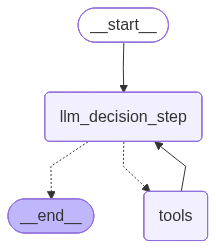

In [ ]:
display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="add 1000 in the current stock price of Apple.")]
messages = react_graph2.invoke({"messages": messages})

In [ ]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 1000 in the current stock price of Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (fc_07a9c617-c1b8-4d7a-adac-e497956da542)
 Call ID: fc_07a9c617-c1b8-4d7a-adac-e497956da542
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $273.81.
================================== Ai Message ==================================
Tool Calls:
  add (fc_77848b2f-e3ca-44ab-98ed-a4eb16af5bca)
 Call ID: fc_77848b2f-e3ca-44ab-98ed-a4eb16af5bca
  Args:
    a: 273.81
    b: 1000
================================= Tool Message =================================
Name: add

1273.81
================================== Ai Message ==================================

The result is **$1,273.81**.


In [ ]:
messages = [HumanMessage(content="can you give me the iphone 17 pro max price.")]
messages = react_graph2.invoke({"messages": messages})

/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: Runtim

In [ ]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

can you give me the iphone 17 pro max price.
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_9abcf80a-c989-4fa4-ae5c-206a84ee97f4)
 Call ID: fc_9abcf80a-c989-4fa4-ae5c-206a84ee97f4
  Args:
    query: iPhone 17 Pro Max price
================================= Tool Message =================================
Name: duckduckgo_search

Get ₹3350.00–₹64000.00 off a new iPhone 17 or iPhone 17 Plus when you trade in an iPhone 7 Plus or newer. Buy now with free shipping. iPhone 17 Pro Max 2 TB: 17.42 cm (6.9″) Display with Promotion, A19 Pro Chip, Best Battery Life in Any iPhone Ever, Pro Fusion Camera System, Center Stage Front Camera; Silver Visit the Apple Store … Dec 16, 2025 · And, the iPhone 17 Pro Max price starts at Rs 1,49,900. One of the most attractive offers is the trade-in deal, which provides significant savings on the new iPhone 17 Pr